In [1]:
import sys
sys.path.insert(0, '..')

import random
import pandas as pd 
from importlib import reload
import MLPModel, LinearModel, Model_Training, DataDownload
import numpy as np

reload(MLPModel)
reload(LinearModel)
reload(Model_Training)

import torch
seed = 22
torch.manual_seed(seed)


In [3]:
tickers = "BTC-USD"

start = '2019-01-01'    # start date
end  = '2026-01-01'     # end date
interval = '1d'         # interval


df_BTC = DataDownload.download_one_data(tickers, start, end, interval).dropna()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,close_log_return,close_cumulative_log_return,open_close_log_diff,overnight_log_gap,cov_lag_1,cov_lag_2,cov_lag_3,cov_lag_12,cov_lag_13,cov_lag_14
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,,,,,,,,,
Date,,,,,,,,,,,,,,,
2019-01-02,3943.409424,3947.981201,3817.409424,3849.216309,5244856836,0.025657,0.025657,1.480953e-03,0.026991,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03,3836.741211,3935.685059,3826.222900,3931.048584,4530215219,-0.027422,-0.001765,-3.139480e-03,0.021037,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-04,3857.717529,3865.934570,3783.853760,3832.040039,4847965467,0.005452,0.003687,-1.226055e-03,-0.025509,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-05,3845.194580,3904.903076,3836.900146,3851.973877,5137609824,-0.003251,0.000436,-1.489983e-03,0.005188,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-06,4076.632568,4093.297363,3826.513184,3836.519043,5597027440,0.058447,0.058883,-2.258751e-03,-0.004020,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,87802.156250,87874.781250,87182.976562,87301.429688,13741199310,0.005719,3.128697,0.000000e+00,0.000755,0.062705,-0.178183,-0.003510,-0.340440,-0.030242,0.219268
2025-12-28,87835.835938,87986.890625,87394.953125,87799.343750,15156557929,0.000384,3.129081,-3.203276e-05,0.005687,0.068784,-0.184115,-0.000161,-0.338163,-0.029127,0.221006


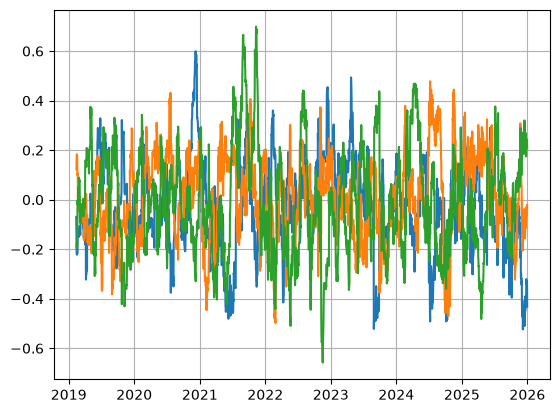

In [10]:
from matplotlib import pyplot as plt 
def verify_covariance_stationarity(df):
    "load a df with close_log_return and check if it is covariance stationary"
    
    dates = pd.to_datetime(df.index)
    for lags in range(12,15):
        df[f"cov_lag_{lags}"] = (df["close_log_return"].rolling(30)
                                 .corr(df['close_log_return'].shift(lags)))
        plt.plot(dates, df[f"cov_lag_{lags}"])
    plt.grid()
    return df
    # pass

verify_covariance_stationarity(df_BTC)



In [ ]:
from 